# Notebook 01 — Data Preprocessing

**Goal**: Load and clean both datasets, align timestamps, and export the processed tweet and match-event tables that all downstream notebooks depend on.

Sections:
1. Environment setup
2. Load raw datasets
3. Clean and filter tweets
4. Inspect match events
5. Build pressure-window aggregates
6. Export processed files

In [1]:
# ── 1. Environment setup ──────────────────────────────────────────────────
# If running on Google Colab, mount Drive and clone the repo first:
#
# from google.colab import drive
# drive.mount('/content/drive')
# !git clone https://github.com/sjekic/nlp-group-project.git
# %cd nlp-group-project
# !pip install -r requirements.txt -q

import sys, os

# Robust path: works whether notebook is run from repo root, notebooks/, or Colab
_nb_dir = os.path.dirname(os.path.abspath(globals().get("__file__", os.getcwd())))
_repo_root = _nb_dir if os.path.isdir(os.path.join(_nb_dir, "src")) else os.path.dirname(_nb_dir)
if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.preprocessing import load_tweets, load_match_events, build_pressure_windows

# ── Paths — change DATA_DIR to your local or Drive path ──────────────────
DATA_DIR    = "../data"
OUTPUT_DIR  = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TWEET_PATH  = f"{DATA_DIR}/premier_league_twitter_comments_match_windows_2020_07_09_to_2020_10_13.csv"
MATCH_PATH  = f"{DATA_DIR}/premier_league_combined_dataset_2020.csv"

In [2]:
# ── 2. Load raw datasets ──────────────────────────────────────────────────
tweets_raw = pd.read_csv(TWEET_PATH)
match_raw  = pd.read_csv(MATCH_PATH)

print(f"Tweets raw shape : {tweets_raw.shape}")
print(f"Match  raw shape : {match_raw.shape}")
tweets_raw.head(3)

Tweets raw shape : (14492, 26)
Match  raw shape : (1475, 45)


,fixture_id,match,kickoff_utc,window_start_utc,window_end_utc,derby,derby_name,home_team,away_team,team_key,...,followers,friends,retweet_count,search_query,text,polarity,location,group_name,partition_0,partition_1
0,11867556,AFC Bournemouth vs Tottenham Hotspur,2020-07-09 17:00:00+00:00,2020-07-09 16:30:00+00:00,2020-07-09 18:55:00+00:00,0,NaN,AFC Bournemouth,Tottenham Hotspur,AFC Bournemouth,...,323,464,0,#Bournemouth,Record attendance and crowd noise at Bournemou...,0.0000,Wakefield,AFC Bournemouth,EPL,AFC Bournemouth
1,11867556,AFC Bournemouth vs Tottenham Hotspur,2020-07-09 17:00:00+00:00,2020-07-09 16:30:00+00:00,2020-07-09 18:55:00+00:00,0,NaN,AFC Bournemouth,Tottenham Hotspur,AFC Bournemouth,...,33,221,0,#Bournemouth,Bournemouth take the lead as Calum Wilson acro...,0.0000,"Manchester, United Kingdom",AFC Bournemouth,EPL,AFC Bournemouth
2,11867556,AFC Bournemouth vs Tottenham Hotspur,2020-07-09 17:00:00+00:00,2020-07-09 16:30:00+00:00,2020-07-09 18:55:00+00:00,0,NaN,AFC Bournemouth,Tottenham Hotspur,AFC Bournemouth,...,8,68,0,#Bournemouth,@CFCDaddy You’d be forgiven for thinking that ...,0.4389,Merseyside,AFC Bournemouth,EPL,AFC Bournemouth


In [3]:
# ── 3. Clean and filter tweets ────────────────────────────────────────────
tweets = load_tweets(TWEET_PATH)

print(f"After cleaning: {len(tweets):,} tweets, {tweets['fixture_id'].nunique()} matches")
print(f"Minute range  : {tweets['relative_minute_from_kickoff'].min():.0f} – {tweets['relative_minute_from_kickoff'].max():.0f}")
print(f"Polarity range: {tweets['polarity'].min():.3f} – {tweets['polarity'].max():.3f}")
tweets[["fixture_id","window_5min","text_clean","polarity"]].head(5)

[load_tweets] 14,474 tweets across 42 matches after filtering.
After cleaning: 14,474 tweets, 42 matches
Minute range  : -30 – 115
Polarity range: -0.985 – 0.984


,fixture_id,window_5min,text_clean,polarity
0,11867556,105,Record attendance and crowd noise at Bournemou...,0.0000
1,11867556,110,Bournemouth take the lead as Calum Wilson acro...,0.0000
2,11867556,110,You’d be forgiven for thinking that this was a...,0.4389
3,11867556,110,Shit that’s a handball Bournemouth EPL Spurs,-0.5574
4,11867556,110,That was definitely a hand-ball but is that th...,0.6908


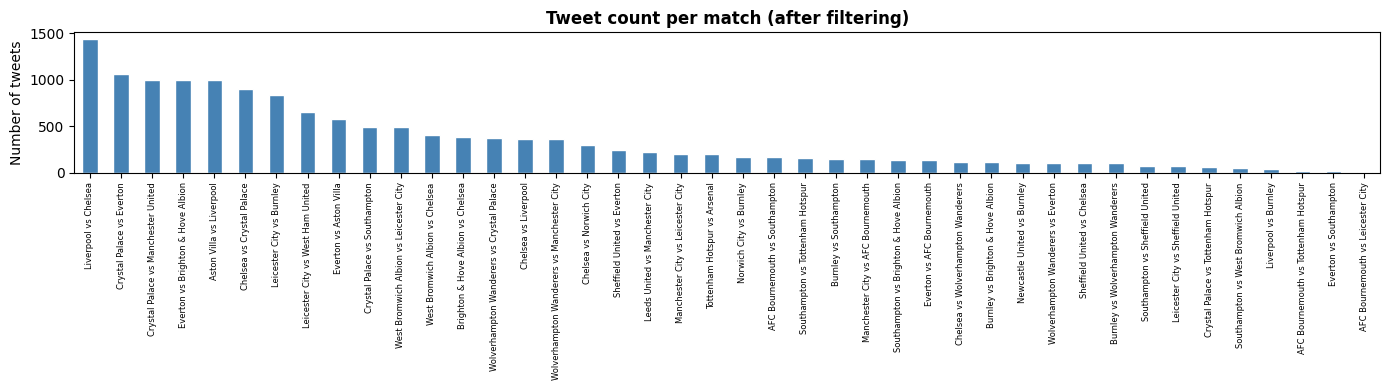

In [4]:
# Tweet count distribution per match
tweet_counts = tweets.groupby("match")["text_clean"].count().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 4))
tweet_counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Tweet count per match (after filtering)", fontsize=12, fontweight="bold")
ax.set_ylabel("Number of tweets")
ax.set_xlabel("")
ax.tick_params(axis="x", labelsize=6, rotation=90)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/tweet_counts_per_match.png", dpi=150)
plt.show()

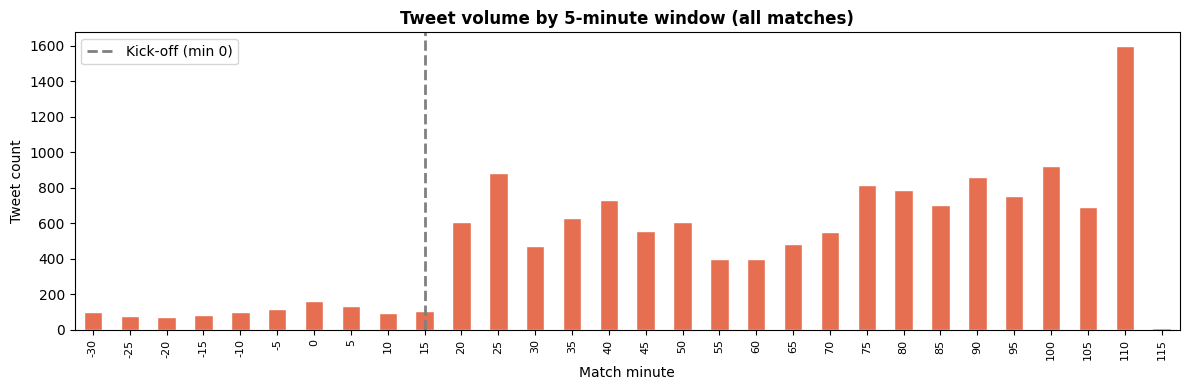

In [5]:
# Tweet volume over match minutes (aggregated across all matches)
minute_vol = tweets.groupby("window_5min").size()

fig, ax = plt.subplots(figsize=(12, 4))
minute_vol.plot(kind="bar", ax=ax, color="#e76f51", edgecolor="white")
ax.set_title("Tweet volume by 5-minute window (all matches)", fontsize=12, fontweight="bold")
ax.set_xlabel("Match minute")
ax.set_ylabel("Tweet count")
ax.tick_params(axis="x", labelsize=8)
ax.axvline(9, color="grey", linewidth=2, linestyle="--", label="Kick-off (min 0)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/tweet_volume_by_minute.png", dpi=150)
plt.show()

In [6]:
# ── 4. Inspect match events ───────────────────────────────────────────────
match_events = load_match_events(MATCH_PATH)

print(f"Match events shape : {match_events.shape}")
print(f"Fixtures           : {match_events['fixture_id'].nunique()}")
print("\nEvent type counts:")
print(match_events['event_type_name'].value_counts().to_string())

[load_match_events] 1,475 rows across 81 matches.
Match events shape : (1475, 29)
Fixtures           : 81

Event type counts:
event_type_name
Substitution      531
Yellowcard        258
Goal              225
period            162
Penalty            35
Redcard            10
Own Goal            6
Missed Penalty      5


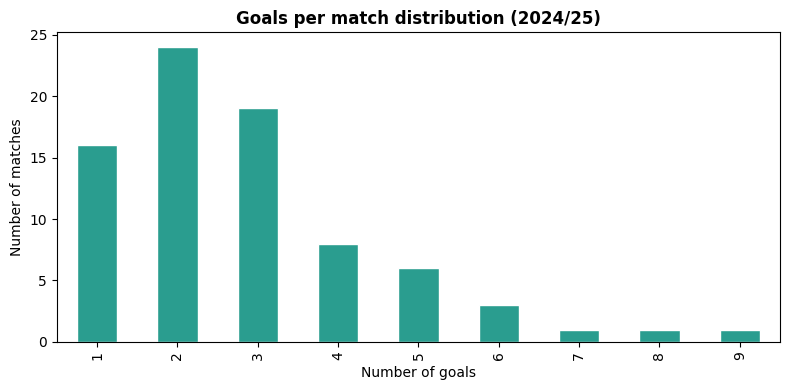

In [7]:
# Goals per match distribution
goals = match_events[match_events["event_type_name"] == "Goal"]
goals_per_match = goals.groupby("fixture_id").size()

fig, ax = plt.subplots(figsize=(8, 4))
goals_per_match.value_counts().sort_index().plot(kind="bar", ax=ax, color="#2a9d8f", edgecolor="white")
ax.set_title("Goals per match distribution (2024/25)", fontsize=12, fontweight="bold")
ax.set_xlabel("Number of goals")
ax.set_ylabel("Number of matches")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/goals_per_match.png", dpi=150)
plt.show()

In [8]:
# ── 5. Build pressure-window aggregates ──────────────────────────────────
pressure_windows = build_pressure_windows(match_events, window_size=5)

print(f"Pressure windows shape: {pressure_windows.shape}")
pressure_windows.describe()

Pressure windows shape: (0, 5)


,fixture_id,window_5min,mean_pressure,max_pressure,high_intensity_count
count,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN


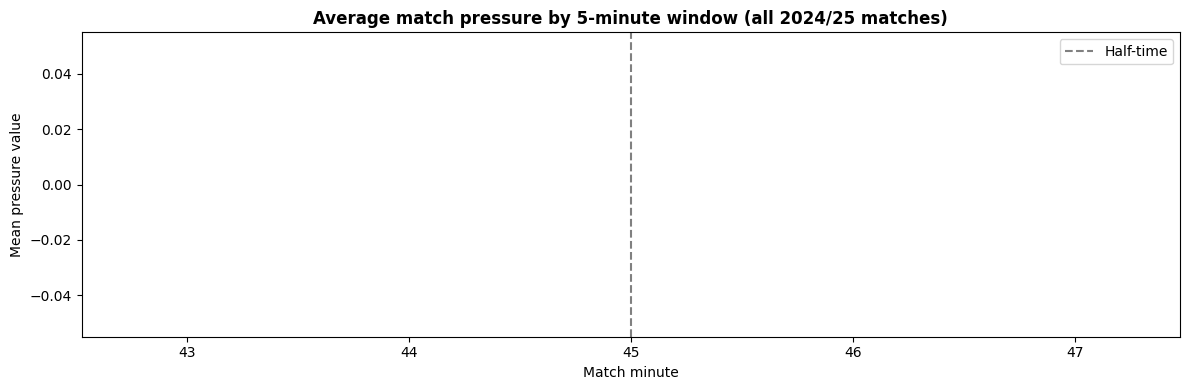

In [9]:
# Pressure distribution over match minutes (all matches)
pressure_by_min = pressure_windows.groupby("window_5min")["mean_pressure"].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(pressure_by_min.index, pressure_by_min.values, alpha=0.5, color="#e63946")
ax.plot(pressure_by_min.index, pressure_by_min.values, color="#e63946", linewidth=2)
ax.axvline(45, color="grey", linestyle="--", linewidth=1.5, label="Half-time")
ax.set_title("Average match pressure by 5-minute window (all 2024/25 matches)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Match minute")
ax.set_ylabel("Mean pressure value")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/pressure_by_minute.png", dpi=150)
plt.show()

In [10]:
# ── 6. Export processed files ─────────────────────────────────────────────
tweets.to_csv(f"{OUTPUT_DIR}/tweets_cleaned.csv", index=False)
match_events.to_csv(f"{OUTPUT_DIR}/match_events_cleaned.csv", index=False)
pressure_windows.to_csv(f"{OUTPUT_DIR}/pressure_windows.csv", index=False)

print("Exported:")
print(f"  {OUTPUT_DIR}/tweets_cleaned.csv")
print(f"  {OUTPUT_DIR}/match_events_cleaned.csv")
print(f"  {OUTPUT_DIR}/pressure_windows.csv")

Exported:
  ../outputs/tweets_cleaned.csv
  ../outputs/match_events_cleaned.csv
  ../outputs/pressure_windows.csv
